In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("DATASET/online_sales_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (49782, 17)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,ShippingCost,Category,SalesChannel,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority
0,221958,SKU_1964,White Mug,38,2020-01-01 00:00,1.71,37039.0,Australia,0.470000,Bank Transfer,10.79,Apparel,In-store,Not Returned,UPS,London,Medium
1,771155,SKU_1241,White Mug,18,2020-01-01 01:00,41.25,19144.0,Spain,0.190000,paypall,9.51,Electronics,Online,Not Returned,UPS,Rome,Medium
2,231932,SKU_1501,Headphones,49,2020-01-01 02:00,29.11,50472.0,Germany,0.350000,Bank Transfer,23.03,Electronics,Online,Returned,UPS,Berlin,High
3,465838,SKU_1760,Desk Lamp,14,2020-01-01 03:00,76.68,96586.0,Netherlands,0.140000,paypall,11.08,Accessories,Online,Not Returned,Royal Mail,Rome,Low
4,359178,SKU_1386,USB Cable,-30,2020-01-01 04:00,-68.11,NaN,United Kingdom,1.501433,Bank Transfer,NaN,Electronics,In-store,Not Returned,FedEx,NaN,Medium


In [3]:
print(df.isna().sum())

InvoiceNo               0
StockCode               0
Description             0
Quantity                0
InvoiceDate             0
UnitPrice               0
CustomerID           4978
Country                 0
Discount                0
PaymentMethod           0
ShippingCost         2489
Category                0
SalesChannel            0
ReturnStatus            0
ShipmentProvider        0
WarehouseLocation    3485
OrderPriority           0
dtype: int64


In [4]:
df.dropna(subset=['CustomerID', 'ShippingCost', 'WarehouseLocation'], inplace=True)
print("After cleaning:", df.shape)

After cleaning: (44804, 17)


In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [6]:
df['Total Sales'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])
df[['Quantity', 'UnitPrice', 'Discount', 'Total Sales']].head()

,Quantity,UnitPrice,Discount,Total Sales
0,38,1.71,0.47,34.4394
1,18,41.25,0.19,601.4250
2,49,29.11,0.35,927.1535
3,14,76.68,0.14,923.2272
5,47,70.16,0.48,1714.7104


In [7]:
top_10_products = df.groupby('Description')['Total Sales'].sum().sort_values(ascending=False).head(10)
print(top_10_products)

Description
White Mug         3.950316e+06
Wall Clock        3.894783e+06
Desk Lamp         3.890642e+06
USB Cable         3.883872e+06
Backpack          3.859457e+06
Blue Pen          3.822014e+06
Headphones        3.818923e+06
Wireless Mouse    3.807658e+06
T-shirt           3.802392e+06
Notebook          3.802158e+06
Name: Total Sales, dtype: float64


In [8]:
df['CustomerID'] = df['CustomerID'].astype('Int64')
top_10_customers = df.groupby('CustomerID')['Total Sales'].sum().sort_values(ascending=False).head(10)
print(top_10_customers)

CustomerID
84431    9777.4939
81067    9678.6503
81631    8690.4065
98923    8655.4714
80001    8547.8395
76402    8235.6824
29700    8033.6615
72172    7874.6906
52808    7843.3884
26371    7723.4536
Name: Total Sales, dtype: float64


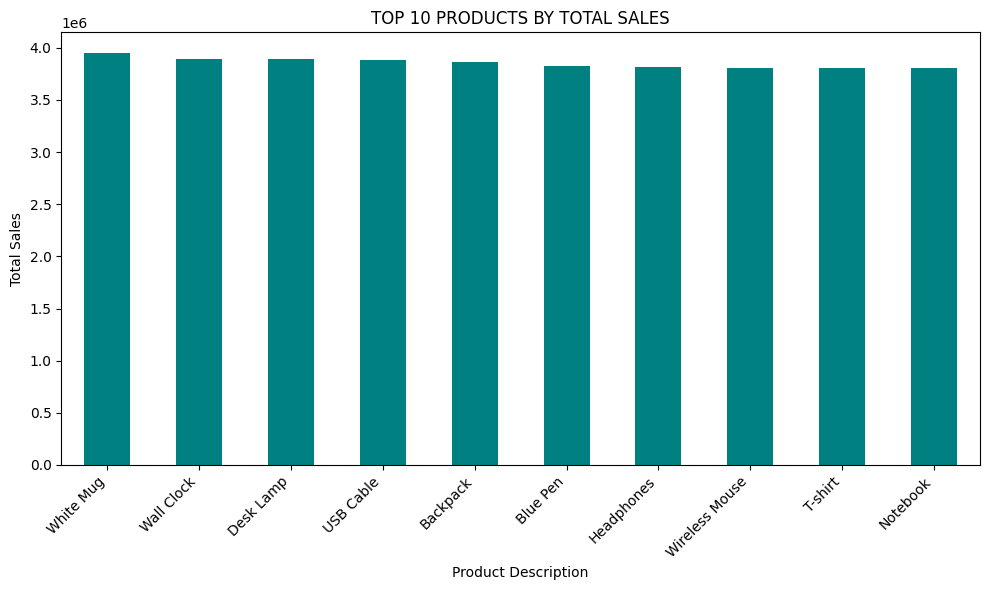

In [9]:
plt.figure(figsize=(10,6))
top_10_products.plot(kind='bar', color='teal')
plt.title("TOP 10 PRODUCTS BY TOTAL SALES")
plt.xlabel("Product Description")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visuals/top_10_products.png')
plt.show()

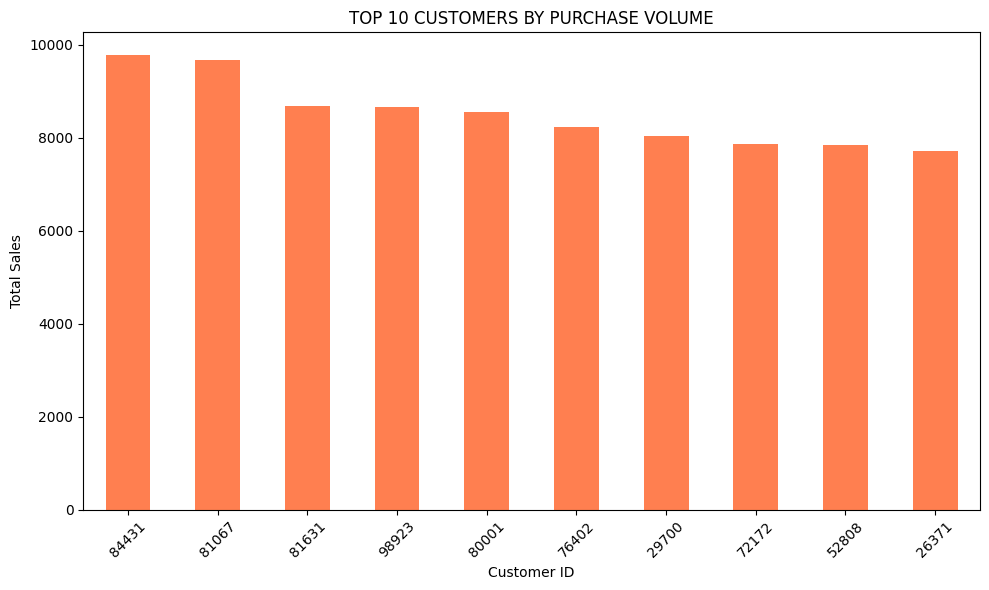

In [10]:
plt.figure(figsize=(10,6))
top_10_customers.plot(kind='bar', color='coral')
plt.title("TOP 10 CUSTOMERS BY PURCHASE VOLUME")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/top_10_customers.png')
plt.show()